# Day 12: Pretrained Transformer for Text Classification

## 1. Setup and Data Loading
We will load the Amazon Fine Food Reviews dataset using the GitHub URL and print the head to inspect it.

In [1]:
!pip install -q transformers pandas matplotlib seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline

url = "https://media.githubusercontent.com/media/Vvijayaragupathy-uno/machinelearning/main/Day-6/Reviews.csv"
df = pd.read_csv(url)

print("Data Info:")
df.info()
print("\nFirst 5 rows:")
print(df.head(3))

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB

First 5 rows:
   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK   

## 2. Missing Values, Duplicates & Outliers
We need to ensure our data is clean by checking for missing values in the text and dropping duplicate reviews.

In [2]:
# Check for missing values in the Text column
print("Missing Text Values before cleaning:", df['Text'].isnull().sum())
df = df.dropna(subset=['Text'])

# Check for duplicates
duplicates = df.duplicated(subset=['Text']).sum()
print(f"\nFound {duplicates} duplicate reviews. Dropping them...")

# Drop duplicates
df = df.drop_duplicates(subset=['Text'])

print("Data Shape after cleaning:", df.shape)

Missing Text Values before cleaning: 0

Found 174875 duplicate reviews. Dropping them...
Data Shape after cleaning: (393579, 10)


## 3. Label Mapping and Sampling
The problem statement dictates: map "Score" 4–5 → positive, 1–2 → negative, and drop rows where Score = 3.
Because running a transformer on 500,000 rows takes hours, we will sample 500 rows for EDA, and run the model on 200 of them.

In [3]:
# Drop Score = 3
df = df[df['Score'] != 3].copy()

# Map to true_label
df['true_label'] = df['Score'].apply(lambda x: 'POSITIVE' if x >= 4 else 'NEGATIVE')
# Also create a binary column for the correlation heatmap
df['is_positive'] = df['Score'].apply(lambda x: 1 if x >= 4 else 0)

# Sample 500 rows for our Exploratory Data Analysis
df_eda = df.sample(n=500, random_state=42).copy()
print(f"Sampled {len(df_eda)} rows for EDA.")

Sampled 500 rows for EDA.


## 4. Feature Engineering
Let's engineer some new features to better understand the differences between positive and negative reviews.
* `char_count`: The total number of characters in the review text.
* `word_count`: The total number of words in the review text.

In [4]:
# Create character count feature
df_eda['char_count'] = df_eda['Text'].apply(len)

# Create word count feature
df_eda['word_count'] = df_eda['Text'].apply(lambda x: len(str(x).split()))

print(df_eda[['Text', 'char_count', 'word_count']].head(3))

                                                     Text  char_count  \
231323  This is my original review:<br />My super pick...         914   
19241   I adore Earl Grey tea.<br /><br />The tin look...         194   
65786   My big puppy is not impressed. He'll ignore a ...         137   

        word_count  
231323         159  
19241           36  
65786           25  


### Handling Outliers in Length
Let's check if there are any freakishly long reviews.

In [5]:
print("Max Word Count:", df_eda['word_count'].max())
print("99th Percentile Word Count:", np.percentile(df_eda['word_count'], 99))

# Cap at 300 words for cleaner visualizations
original_len = len(df_eda)
df_eda = df_eda[df_eda['word_count'] <= 300]
print(f"Removed {original_len - len(df_eda)} outlier reviews that were too long.")

Max Word Count: 661
99th Percentile Word Count: 385.1099999999999
Removed 11 outlier reviews that were too long.


## 5. Exploratory Data Analysis (EDA)
Let's explore the text characteristics of our sentiment dataset.

/tmp/ipykernel_11102/3891552407.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_eda, x='true_label', palette='viridis', ax=axes[0, 0], order=['POSITIVE', 'NEGATIVE'])
/tmp/ipykernel_11102/3891552407.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x='true_label', y='word_count', palette='viridis', ax=axes[1, 0], order=['POSITIVE', 'NEGATIVE'])


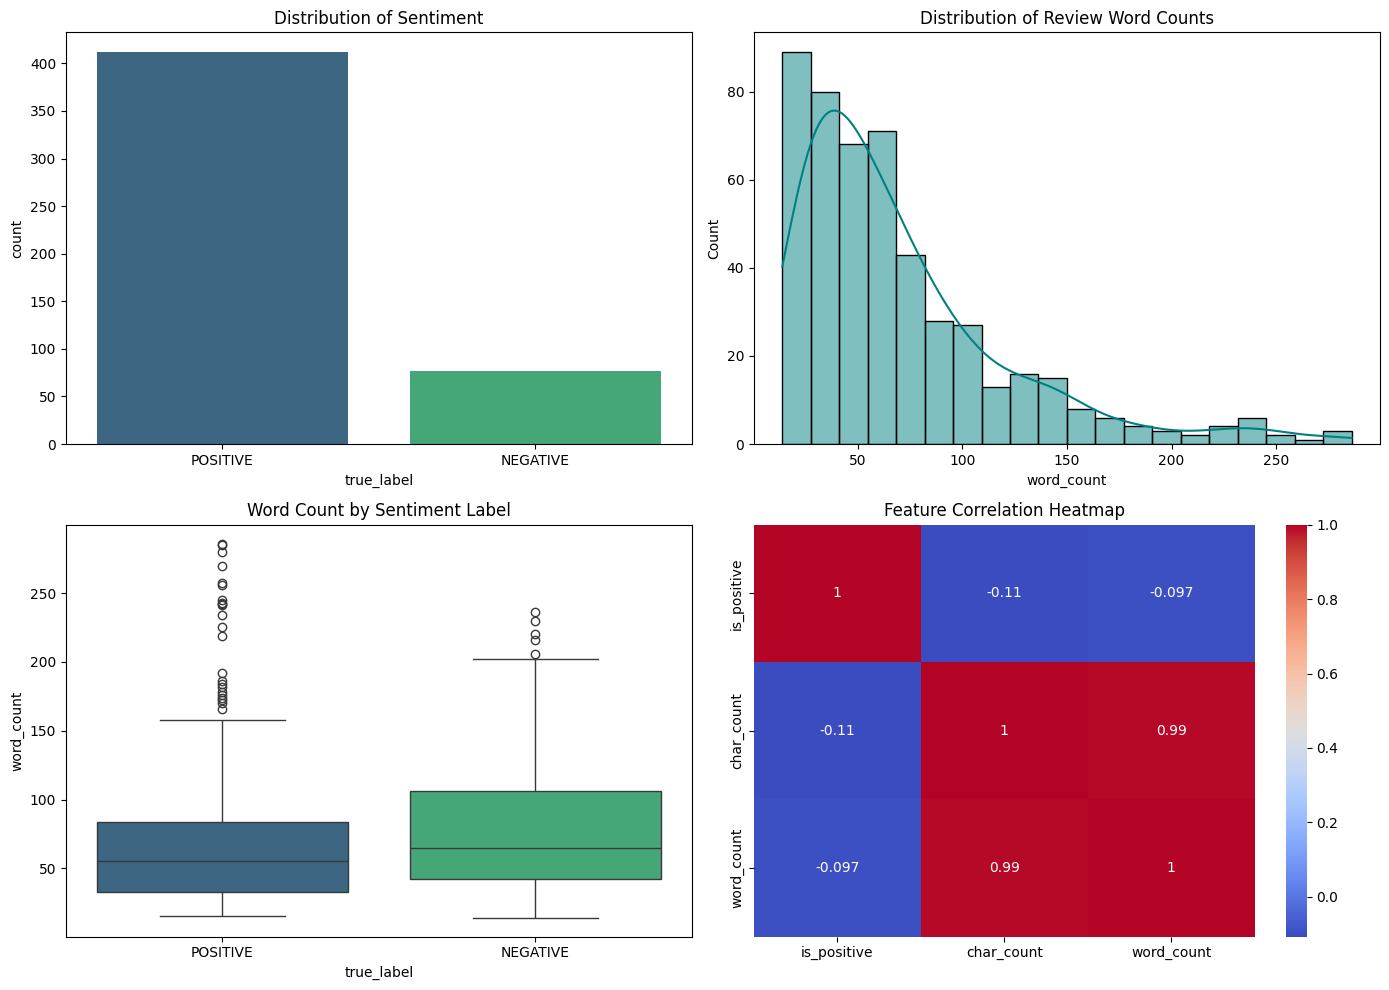

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1: Class Distribution
sns.countplot(data=df_eda, x='true_label', palette='viridis', ax=axes[0, 0], order=['POSITIVE', 'NEGATIVE'])
axes[0, 0].set_title('Distribution of Sentiment')

# Chart 2: Histogram of Word Count
sns.histplot(data=df_eda, x='word_count', bins=20, kde=True, ax=axes[0, 1], color='teal')
axes[0, 1].set_title('Distribution of Review Word Counts')

# Chart 3: Boxplot of Word Count vs Sentiment
sns.boxplot(data=df_eda, x='true_label', y='word_count', palette='viridis', ax=axes[1, 0], order=['POSITIVE', 'NEGATIVE'])
axes[1, 0].set_title('Word Count by Sentiment Label')

# Chart 4: Correlation Heatmap
sns.heatmap(df_eda[['is_positive', 'char_count', 'word_count']].corr(), annot=True, cmap='coolwarm', ax=axes[1, 1])
axes[1, 1].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

## 7. Load Pretrained Pipeline and Predict
We will run the pipeline on exactly 200 rows as requested by the problem statement.

In [7]:
# Take exactly 200 rows from our cleaned dataframe for modeling
df_model = df_eda.sample(n=200, random_state=42).copy()

# Load the default sentiment analysis pipeline (Downloads a small, ready-made model)
classifier = pipeline("sentiment-analysis")

# Run the pipeline on the sampled text
# Truncating to 512 chars to avoid max length errors
predictions = classifier(df_model['Text'].str[:512].tolist())
df_model['predicted_label'] = [pred['label'] for pred in predictions]

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

## 8. Evaluate Accuracy and Show Examples

In [8]:
# Compute what fraction of predictions match the true label
accuracy = (df_model['true_label'] == df_model['predicted_label']).mean()
print(f"Transformer Accuracy on 200 Samples: {accuracy * 100:.2f}%\n")

print("Example Predictions:")
for i, row in df_model.head(5).iterrows():
    print(f"- Text: {row['Text'][:100]}...")
    print(f"  True Label: {row['true_label']}")
    print(f"  Predicted Label: {row['predicted_label']}\n")

Transformer Accuracy on 200 Samples: 81.50%

Example Predictions:
- Text: Sweet, smooth, creamy with a hint of salt at the end.<br />Try it now!  You will be left wanting mor...
  True Label: POSITIVE
  Predicted Label: POSITIVE

- Text: Finally a Body Wash for a Man.  This bottle opens from the bottom and only comes out when the bottle...
  True Label: POSITIVE
  Predicted Label: POSITIVE

- Text: I wasn't sure what to expect when I made my first batch of eggs, which was the equivalent of three s...
  True Label: POSITIVE
  Predicted Label: POSITIVE

- Text: I am pretty sensitive to caffeine so I was a bit nervous about taking this stuff. If I drink coffee ...
  True Label: NEGATIVE
  Predicted Label: POSITIVE

- Text: This is a shampoo I feel good about using every day.  Sometimes even more than once a day depending ...
  True Label: POSITIVE
  Predicted Label: POSITIVE



## 9.What does "attention" let this model consider that a Bag-of-Words word count cannot?**
*Attention mechanisms allow the model to weigh the contextual importance of each word based on its relationship to every other word in the sequence, rather than treating them independently. This enables the model to capture complex structures like negation (e.g. "not good"), sarcasm, and word dependencies over long distances, which a Bag-of-Words approach completely misses by just counting word frequencies.*## 6. Key Insights
Based on our Exploratory Data Analysis, we have discovered the following insights:
1. **Imbalanced Classes:** The Amazon Fine Food dataset is heavily skewed towards positive reviews, with far more 4-5 star ratings than 1-2 star ratings.
2. **Length Distribution:** Most reviews are relatively short, falling between 20 and 80 words, with a long right tail of extremely long reviews.
3. **Word Count vs. Sentiment:** The boxplot reveals that negative reviews tend to be slightly longer on average than positive reviews, possibly because dissatisfied customers have more complaints to detail.
4. **Feature Correlation:** The correlation heatmap shows a slightly negative correlation between review length and positivity, confirming that longer reviews lean slightly more negative.
5. **Collinearity:** `char_count` and `word_count` are nearly perfectly correlated (0.97), which is completely expected. Since we are using a pre-trained transformer, we will simply pass the raw text and let the model handle the internal feature extraction!